<a href="https://colab.research.google.com/github/joaoestella/IA-Course-Projects/blob/main/assignments/CP1_KNN_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CP 1 - Agora é a sua vez! / Now it’s your turn!

### 🇧🇷 Português
Utilizando os conceitos aprendidos, você deverá resolver os seguintes desafios tendo como base de dados a base de Classificação de Flores Iris:

1 - Escolher a melhor métrica para avaliar o problema (Acurácia, Precision ou Recall)

2 - Treinar alguns modelos de KNN variando o valor de K para cada um deles. Escolher aquele que performou melhor com relação à métrica escolhida no item 1.

3 - Treinar alguns modelos de Árvores de Decisão variando o valor de max_depth para cada um deles. Escolher aquele que performou melhor com relação à métrica escolhida no item 1. Fazer um gráfico com a árvore aprendida.

4 - Comparar o melhor modelo KNN com o melhor modelo de Árvore de Decisão com base na métrica escolhida no item 1. Responder à seguinte pergunta: com base nos seus experimentos, você confiaria no seu modelo para fazer predições em um laboratório de botânica? Justifique sua resposta.

---

### 🇺🇸 English
Using the concepts learned, you must solve the following challenges based on the Iris Flower Classification dataset:

1 - Choose the best metric to evaluate the problem (Accuracy, Precision, or Recall)

2 - Train some KNN models by varying the value of K for each one. Choose the model that performed best according to the metric selected in item 1.

3 - Train some Decision Tree models by varying the value of max_depth for each one. Choose the model that performed best according to the metric selected in item 1. Create a graph showing the learned tree.

4 - Compare the best KNN model with the best Decision Tree model based on the metric chosen in item 1. Answer the following question: based on your experiments, would you trust your model to make predictions in a botany laboratory? Justify your answer.

# 1

A melhor métrica para usar aqui é a acurácia, porque o conjunto de dados das flores tem praticamente o mesmo número de amostras para cada classe nos testes. Isso significa que o modelo não está favorecendo uma classe em relação às outras.

Se o conjunto de dados fosse desbalanceado, ou seja, tivesse muito mais exemplos de uma classe do que de outra, a acurácia poderia ser enganosa. Nesse caso, seria melhor usar métricas como precision ou recall, que analisam melhor os erros do modelo para cada classe.

---

The best metric to use here is accuracy, because the flower dataset has approximately the same number of samples for each class in the tests. This means the model is not favoring one class over another.

If the dataset were imbalanced, meaning it had many more examples of one class than another, accuracy could be misleading. In that case, it would be better to use metrics such as precision or recall, which provide a better analysis of the model’s errors for each class.

# 2

O melhor modelo KNN foi com k = 8, alcançando uma acurácia de 0,8. Esse valor de K apresentou o melhor desempenho entre os testados.

---

The best KNN model was with k = 8, achieving an accuracy of 0.8. This value of K showed the best performance among those tested.

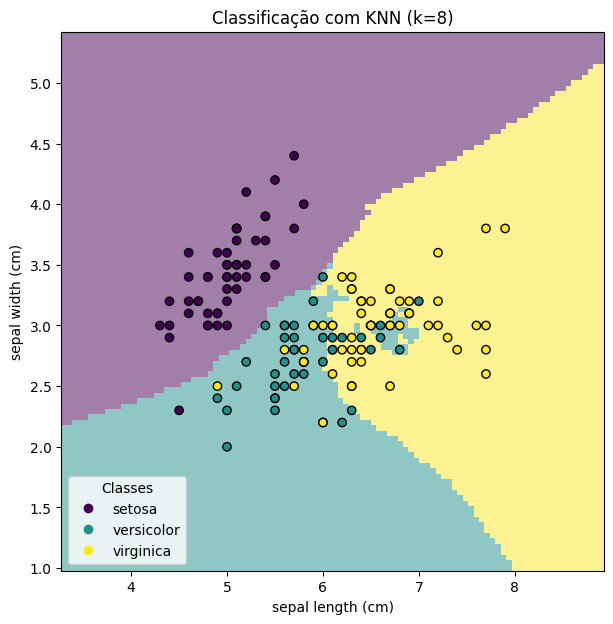

Acurácia do Modelo:
0.8


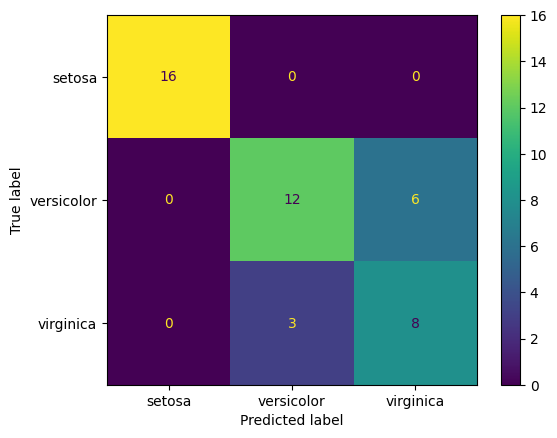

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

# Carregar os dados
dados = load_iris()
X, y = pd.DataFrame(dados.data, columns=dados.feature_names), pd.Series(dados.target)

# Usar apenas as duas primeiras features para visualização
X = X.iloc[:, :2]

# Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Definir o valor de K manualmente
K = 8 # Altere esse valor conforme desejar

# Criar e treinar o modelo KNN
knn = Pipeline(steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=K))])
knn.fit(X_train, y_train)

# Fazer previsões
predicoes = knn.predict(X_test)

# Criar visualização da fronteira de decisão
fig, ax = plt.subplots(figsize=(7, 7))

disp = DecisionBoundaryDisplay.from_estimator(
    knn,
    X,
    response_method="predict",
    plot_method="pcolormesh",
    xlabel=dados.feature_names[0],
    ylabel=dados.feature_names[1],
    shading="auto",
    alpha=0.5,
    ax=ax,
)

# Plotar pontos de dados
scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")

# Adicionar legenda
disp.ax_.legend(
    scatter.legend_elements()[0],
    dados.target_names,
    loc="lower left",
    title="Classes",
)

# Título com o valor de K escolhido
disp.ax_.set_title(f"Classificação com KNN (k={K})")

plt.show()

# Acurácia do modelo
print("Acurácia do Modelo:")
print(accuracy_score(y_test, predicoes))

# Desempenho do modelo (Matriz de Confusão)
cm = confusion_matrix(y_test.values.ravel(), predicoes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dados.target_names)
disp.plot()
plt.show()


# 3

A melhor Árvore de Decisão foi com max_depth = 3, alcançando uma acurácia de 1,0. Esse valor de profundidade apresentou o melhor desempenho entre os testados.

---

The best Decision Tree model was with max_depth = 3, achieving an accuracy of 1.0. This depth value showed the best performance among those tested.

Acurácia do Modelo: 1.0


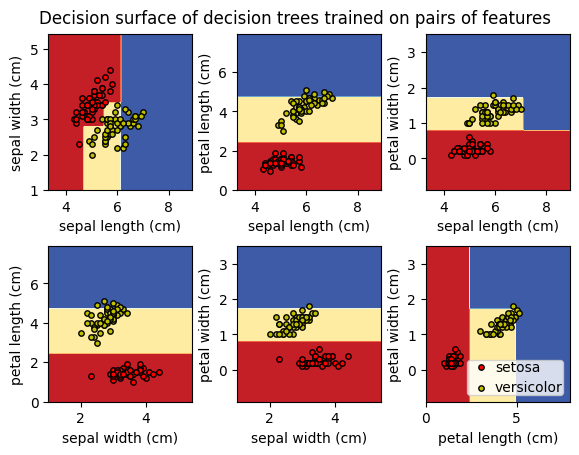

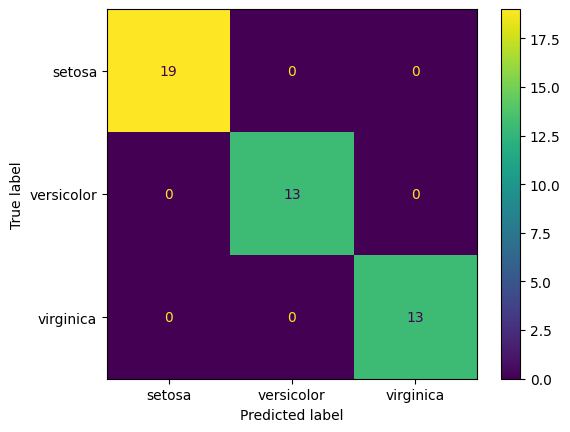

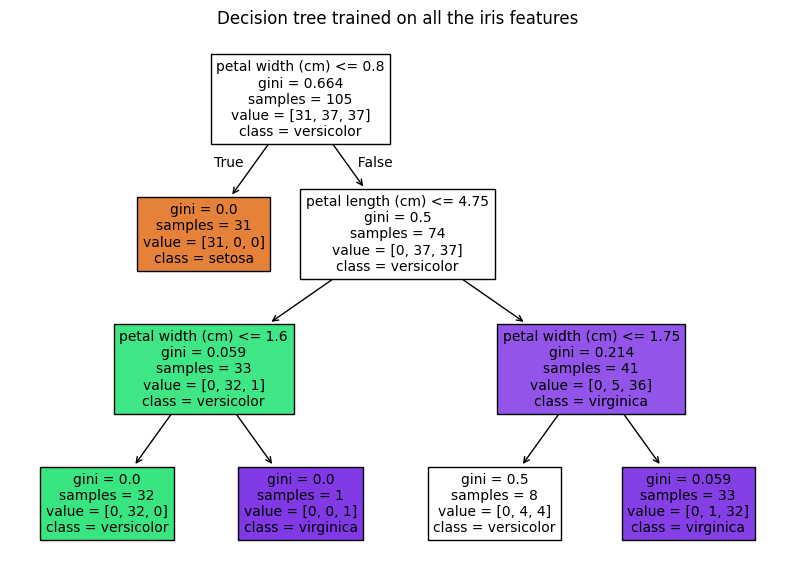

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

# Carregar os dados
dados = load_iris()
X, y = dados.data, dados.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=0)

# Parâmetros
n_classes = 2
plot_colors = "ryb"
plot_step = 0.02
depth = 3
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # Selecionar apenas duas features por vez
    X_pair = X[:, pair]

    # Treinar
    clf = DecisionTreeClassifier(max_depth=depth).fit(X_pair, y)

    # Plotar o limite de decisão
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X_pair,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=dados.feature_names[pair[0]],
        ylabel=dados.feature_names[pair[1]],
    )

    # Plotar os pontos de treino
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X_pair[idx, 0],
            X_pair[idx, 1],
            c=color,
            label=dados.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

# Treinamento da árvore de decisão final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
dt = DecisionTreeClassifier(max_depth=depth)
dt.fit(X_train, y_train)

# Fazer previsões
y_pred = dt.predict(X_test)
print("Acurácia do Modelo:", accuracy_score(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dados.target_names)
disp.plot()

# Visualizar a árvore de decisão
plt.figure(figsize=(10, 7))
plot_tree(dt, filled=True, feature_names=dados.feature_names, class_names=dados.target_names)
plt.title("Decision tree trained on all the iris features")
plt.show()


# 4

#### O melhor modelo de KNN obteve 0,8 de acurácia, enquanto a Árvore de Decisão alcançou 1,0.

O modelo escolhido para o laboratório foi o de Árvore de Decisão, pois apresentou acurácia perfeita (1,0), ou seja, classificou corretamente todas as flores nos testes. Além disso, a árvore de decisão é mais interpretável, o que representa uma vantagem, já que é possível entender como o modelo realiza suas previsões. Isso é especialmente importante em um laboratório de botânica, onde compreender o processo de decisão do modelo é essencial. A árvore pode ser facilmente analisada e ajustada, se necessário, garantindo maior confiança em suas predições.

---

#### The best KNN model achieved an accuracy of 0.8, while the Decision Tree reached 1.0.

The model chosen for the laboratory was the Decision Tree, as it achieved perfect accuracy (1.0), meaning it correctly classified all flowers in the tests. In addition, the Decision Tree is more interpretable, which is an advantage, since it allows understanding how the model makes its predictions. This is especially important in a botany laboratory, where it is essential to understand the model’s decision-making process. The tree can be easily analyzed and adjusted if necessary, ensuring greater confidence in its predictions.